In [3]:
import torch
torch.cuda.empty_cache()

In [4]:
!pip install -q transformers datasets peft accelerate
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [5]:
!unzip -q '/content/drive/MyDrive/indic_marathi_cleaned.zip' -d indic_marathi_cleaned

In [6]:
!unzip -q '/content/drive/MyDrive/llama_1b_stage1_marathi_qlora.zip' -d llama_1b_stage_1_marathi_qlora

In [7]:
import os
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer
)
from peft import PeftModel, LoraConfig, get_peft_model

In [8]:
BASE_MODEL_PATH = "/content/drive/MyDrive/llama_models/llama3_2_1b"
STAGE1_ADAPTER_PATH = '/content/llama_1b_stage_1_marathi_qlora/checkpoint-702'
STAGE2_OUTPUT_DIR = "/content/drive/MyDrive/llama_stage2_marathi_qlora"

TRAIN_PATH = 'indic_marathi_cleaned/indic_marathi_cleaned/train.csv'
VAL_PATH = 'indic_marathi_cleaned/indic_marathi_cleaned/validation.csv'
TEST_PATH = 'indic_marathi_cleaned/indic_marathi_cleaned/test.csv'

**Maximum Token Length Estimation**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np

_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH)

In [ ]:
_dataset = load_dataset("csv", data_files={"data": TRAIN_PATH})
_data = _dataset["data"]

Generating data split: 0 examples [00:00, ? examples/s]

In [ ]:
article_lengths = []
summary_lengths = []
total_prompt_lengths = []

instruction_text = "खालील मजकुराचा थोडक्यात आणि अचूक सारांश द्या.\n\nमजकूर:\n"
response_text = "\n\nसारांश:\n"

instruction_tokens = _tokenizer(instruction_text, add_special_tokens=False)["input_ids"]
response_tokens = _tokenizer(response_text, add_special_tokens=False)["input_ids"]

for example in _data:

    article_tokens = _tokenizer(
        example["input"],
        add_special_tokens=False
    )["input_ids"]

    summary_tokens = _tokenizer(
        example["target"],
        add_special_tokens=False
    )["input_ids"]

    article_lengths.append(len(article_tokens))
    summary_lengths.append(len(summary_tokens))

    total_length = (
        len(instruction_tokens)
        + len(article_tokens)
        + len(response_tokens)
        + len(summary_tokens)
    )

    total_prompt_lengths.append(total_length)

In [ ]:
def print_stats(name, values):
    print(f"\n{name} Token Statistics:")
    print(f"Mean: {np.mean(values):.2f}")
    print(f"Median: {np.median(values):.2f}")
    print(f'75th Percentile: {np.percentile(values, 75):.2f}')
    print(f"90th Percentile: {np.percentile(values, 90):.2f}")
    print(f"95th Percentile: {np.percentile(values, 95):.2f}")
    print(f"99th Percentile: {np.percentile(values, 99):.2f}")
    print(f"Max: {np.max(values)}")

print_stats("Article", article_lengths)
print_stats("Summary", summary_lengths)
print_stats("Total Prompt", total_prompt_lengths)


Article Token Statistics:
Mean: 75.92
Median: 72.00
75th Percentile: 90.00
90th Percentile: 109.00
95th Percentile: 122.00
99th Percentile: 148.00
Max: 187

Summary Token Statistics:
Mean: 30.99
Median: 30.00
75th Percentile: 37.00
90th Percentile: 43.00
95th Percentile: 46.00
99th Percentile: 51.00
Max: 59

Total Prompt Token Statistics:
Mean: 143.91
Median: 141.00
75th Percentile: 160.00
90th Percentile: 180.00
95th Percentile: 195.00
99th Percentile: 225.00
Max: 274


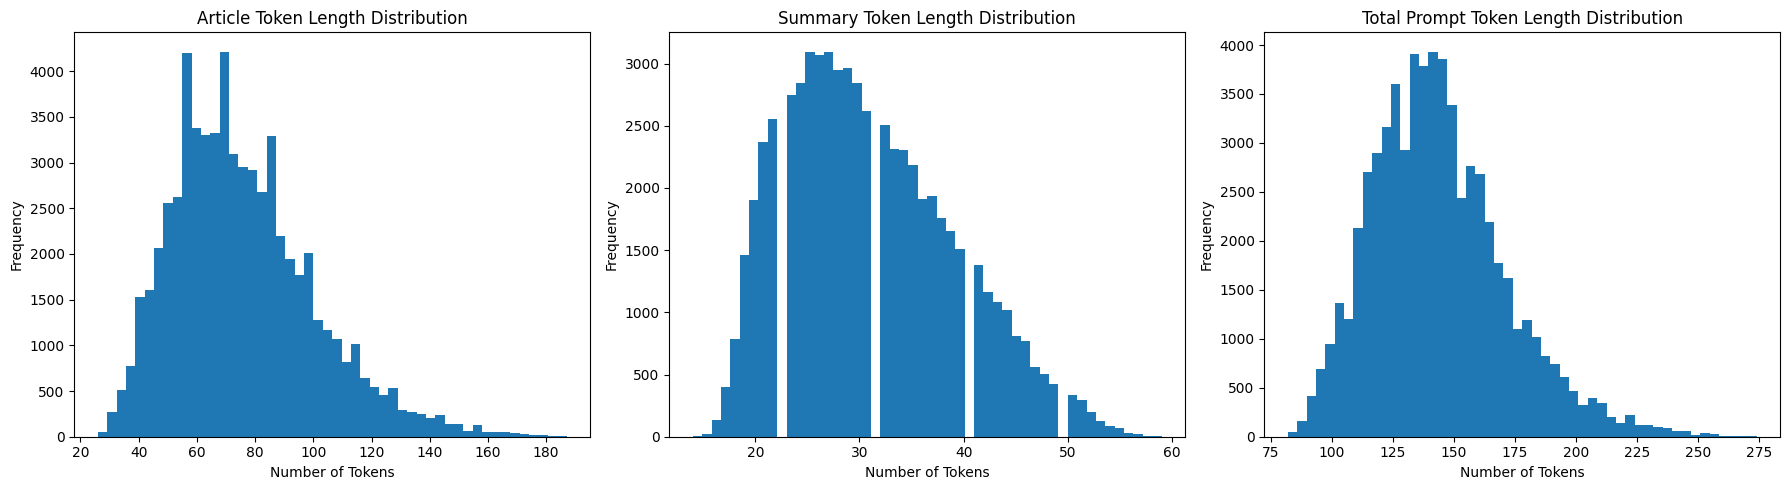

In [ ]:
import matplotlib.pyplot as plt

def plot_token_distributions(article_lengths, summary_lengths, total_prompt_lengths):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Article Tokens
    axes[0].hist(article_lengths, bins=50)
    axes[0].set_title("Article Token Length Distribution")
    axes[0].set_xlabel("Number of Tokens")
    axes[0].set_ylabel("Frequency")

    # Summary Tokens
    axes[1].hist(summary_lengths, bins=50)
    axes[1].set_title("Summary Token Length Distribution")
    axes[1].set_xlabel("Number of Tokens")
    axes[1].set_ylabel("Frequency")

    # Total Prompt Tokens
    axes[2].hist(total_prompt_lengths, bins=50)
    axes[2].set_title("Total Prompt Token Length Distribution")
    axes[2].set_xlabel("Number of Tokens")
    axes[2].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# Call function
plot_token_distributions(article_lengths, summary_lengths, total_prompt_lengths)

In [ ]:
eos_id = _tokenizer.eos_token_id

count = 0

for ex in dataset["train"]:
    if eos_id in ex["input_ids"]:
        count += 1

print(count / len(dataset["train"]))

NameError: name 'dataset' is not defined

Training

In [9]:
import pandas as pd

df = pd.read_csv(TRAIN_PATH)
df.head()

,Unnamed: 0,input,target
0,0,उपमुख्यमंत्री अजित पवार ः आम्ही सर्वजण उद्धव ठ...,मतभिन्नता असली तरी महाविकास आघाडी मजबूतच - अजि...
1,1,टीम महाराष्ट्र देशा : भारतीय हवाई दलाने नियंत्...,"मुख्यमंत्री आणि पोलीस यांच्यातील बैठक संपली , ..."
2,2,सांगली - सांगली शहरातील 100 फुटी रोड परिसरात न...,सांगलीत अज्ञातांकडून वाहनांची जाळपोळ
3,3,ऱ्या पावसामुळे महाराष्ट्रावर भीषण दुष्काळाचे स...,जालन्यात पाणी टंचाईने घेतला महिलेचा जीव
4,4,मुंबईत मुख्यमंत्री देवेंद्र फडणवीस यांच्या हस्...,लोकशाहीर अण्णाभाऊ साठे यांच्या टपाल तिकिटाचे ग...


In [10]:
dataset = load_dataset(
    "csv",
    data_files={
        "train": TRAIN_PATH,
        "validation": VAL_PATH,
        "test": TEST_PATH
    }
)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [11]:
dataset = dataset.shuffle(seed=42)

In [12]:
print(dataset["train"].column_names)

['Unnamed: 0', 'input', 'target']


In [13]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH)
tokenizer.pad_token = tokenizer.eos_token

In [14]:
# def format_example(example):
#     prompt = f"""### Instruction:
#               खाली दिलेल्या मराठी मजकुराचा थोडक्यात सारांश लिहा.

#               ### Input:
#               {example['article']}

#               ### Response:
#               """
#     full_text = prompt + example["summary"]
#     return {"text": full_text}

# dataset = dataset.map(format_example)

In [15]:
# def tokenize(example):
#     tokens = tokenizer(
#         example["text"],
#         truncation=True,
#         max_length=1024,
#         padding="max_length"
#     )

#     # Mask everything except summary
#     prompt = example["text"].split("### Response:")[0] + "### Response:\n"
#     prompt_len = len(tokenizer(prompt)["input_ids"])

#     labels = tokens["input_ids"].copy()
#     labels[:prompt_len] = [-100] * prompt_len

#     tokens["labels"] = labels
#     return tokens

# dataset = dataset.map(tokenize, remove_columns=dataset["train"].column_names)

In [16]:
import torch
torch.cuda.empty_cache()

In [17]:
# 4. Bulletproof Tokenization Logic (Array Concatenation)
def tokenize(example):
    prompt = (
        "खालील मजकुराचा थोडक्यात आणि अचूक सारांश द्या.\n\n"
        f"मजकूर:\n{example['input']}"
        "\n\nसारांश:\n"
    )

    # Tokenize components completely independently to eliminate boundary shift bugs
    prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)
    target_ids = tokenizer.encode(str(example['target']), add_special_tokens=False)

    # Append the true EOS token specifically to the end of your target summary sequences
    eos_id = [tokenizer.eos_token_id]

    # Construct input configurations explicitly
    input_ids = prompt_ids + target_ids + eos_id

    # Strictly mask out prompt IDs with -100 while keeping target IDs and the EOS token raw
    labels = [-100] * len(prompt_ids) + target_ids + eos_id

    return {
        "input_ids": input_ids,
        "attention_mask": [1] * len(input_ids),
        "labels": labels
    }

# Map dataset and strip old columns
dataset = dataset.map(
    tokenize,
    remove_columns=dataset["train"].column_names
)

Map:   0%|          | 0/62793 [00:00<?, ? examples/s]

Map:   0%|          | 0/8010 [00:00<?, ? examples/s]

Map:   0%|          | 0/7902 [00:00<?, ? examples/s]

In [18]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    padding=True,
    return_tensors="pt"
)

In [19]:
batch = data_collator([dataset["train"][0], dataset["train"][1]])

print(batch["labels"])

tensor([[  -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100, 102393,
          88344, 101358,  44747,  84736, 101391, 101358,  24810, 103549, 100273,
          69258, 100750, 113

In [20]:
print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

torch.Size([2, 123])
torch.Size([2, 123])
torch.Size([2, 123])


In [21]:
print('EOS token id : ', tokenizer.eos_token_id)

EOS token id :  128001


In [22]:
eos_id = tokenizer.eos_token_id

count = 0

for sample in dataset["train"]:
    if eos_id in sample["labels"]:
        count += 1

print(f"EOS coverage: {count}/{len(dataset['train'])}")
print(f"Percentage: {100*count/len(dataset['train']):.2f}%")

EOS coverage: 62793/62793
Percentage: 100.00%


In [23]:
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_PATH,
    dtype=torch.float16,
    device_map="auto"
)

model = PeftModel.from_pretrained(base_model, STAGE1_ADAPTER_PATH)

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

In [24]:
model.print_trainable_parameters()

trainable params: 0 || all params: 1,239,222,272 || trainable%: 0.0000


In [25]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)
        break

In [26]:
def is_valid_adapter(path):
    if not os.path.isdir(path):
        return False

    config = os.path.exists(os.path.join(path, "adapter_config.json"))
    weights = (
        os.path.exists(os.path.join(path, "adapter_model.safetensors")) or
        os.path.exists(os.path.join(path, "adapter_model.bin"))
    )

    return config and weights

In [27]:
from transformers.trainer_utils import get_last_checkpoint

def get_stage2_adapter_path(output_dir):
    # First try root
    if is_valid_adapter(output_dir):
        return output_dir

    # Otherwise try latest checkpoint
    last_checkpoint = get_last_checkpoint(output_dir)
    if last_checkpoint and is_valid_adapter(last_checkpoint):
        return last_checkpoint
    return None

In [28]:
# adapter_path = get_stage2_adapter_path(STAGE2_OUTPUT_DIR)

# if adapter_path is not None:
#     print("Loading existing Stage-2 adapter...")
#     model = PeftModel.from_pretrained(model, adapter_path)
# else:
#     print("Creating new Stage-2 adapter...")

#     lora_config = LoraConfig(
#         r=64,
#         lora_alpha=128,
#         target_modules=["q_proj","k_proj","v_proj","o_proj"],
#         lora_dropout=0.05,
#         bias="none",
#         task_type="CAUSAL_LM"
#     )
#     model = get_peft_model(model, lora_config)

In [29]:
# from transformers.trainer_utils import get_last_checkpoint

# last_checkpoint = get_last_checkpoint(STAGE2_OUTPUT_DIR)

# if last_checkpoint is None:
#     print("Creating new Stage-2 adapter...")

#     lora_config = LoraConfig(
#         r=64,
#         lora_alpha=128,
#         target_modules=["q_proj","k_proj","v_proj","o_proj"],
#         lora_dropout=0.05,
#         bias="none",
#         task_type="CAUSAL_LM"
#     )

#     model = get_peft_model(model, lora_config)

# else:
#     print("Checkpoint exists → Trainer will handle loading")

In [ ]:
!mkdir -p /content/drive/MyDrive/llama_stage2_marathi_qlora

In [30]:
from transformers.trainer_utils import get_last_checkpoint

last_checkpoint = get_last_checkpoint(STAGE2_OUTPUT_DIR)

# ALWAYS create LoRA structure first
# Expanded target modules for comprehensive task adaptation
lora_config = LoraConfig(
    r=48,
    lora_alpha=96,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

if last_checkpoint:
    print("Resuming from:", last_checkpoint)

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Resuming from: /content/drive/MyDrive/llama_stage2_marathi_qlora/checkpoint-6000


In [31]:
model.print_trainable_parameters()

trainable params: 33,816,576 || all params: 1,269,630,976 || trainable%: 2.6635


In [32]:
sample = dataset["train"][0]

print(len(sample["input_ids"]))
print(len(sample["labels"]))

print(tokenizer.decode(
    [x for x in sample["labels"] if x != -100]
))

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


122
122
आम्ही पुन्हा सरकार स्थापन करू : विनोद तावडे<|end_of_text|>


In [33]:
model.gradient_checkpointing_enable()
model.config.use_cache = False  # VERY IMPORTANT

In [34]:
training_args = TrainingArguments(
    output_dir=STAGE2_OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    fp16=True,

    optim='adamw_torch',
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    label_smoothing_factor=0.0,
    weight_decay=0.01,
    max_grad_norm=0.5,

    # eval_strategy="epoch",
    # save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=500,
    save_steps=500,
    logging_steps=50,
    save_total_limit=2,
    dataloader_drop_last=False,
    report_to="none"
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [35]:
import transformers
print(transformers.__version__)

5.9.0


In [36]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator
)

In [ ]:
from transformers.trainer_utils import get_last_checkpoint

last_checkpoint = get_last_checkpoint(STAGE2_OUTPUT_DIR)

if last_checkpoint is not None:
    print("Resuming from:", last_checkpoint)
    trainer.train(resume_from_checkpoint=last_checkpoint)
else:
    print("Starting fresh.....")
    trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 128001}.


Resuming from: /content/drive/MyDrive/llama_stage2_marathi_qlora/checkpoint-6000


Step,Training Loss,Validation Loss
6500,0.967065,1.443145
7000,0.949010,1.438816
7500,0.984555,1.455131
8000,0.870831,1.502405
8500,0.804894,1.516713
9000,0.797799,1.527003
9500,0.815241,1.533701


In [ ]:
trainer.save_model(STAGE2_OUTPUT_DIR )

In [ ]:
trainer.save_model('/content/drive/MyDrive/llama_stage2_marathi_qlora_copy')

In [ ]:
trainer.save_model('/content/drive/MyDrive/llama_stage2_marathi_qlora_2_copy')

In [ ]:
trainer.save_model('/content/drive/MyDrive/llama_stage2_marathi_qlora_3_copy')